# Scenario B2 Forecasts Mixed: Multiple Suppliers with REC — Explicit Forecast Scheduling (Mixed Prosumers)

**Description:** Multi-supplier REC scenario identical to B2-mixed but where DA and ID market scheduling
uses dedicated per-participant forecast CSV files rather than falling back to actuals. Prosumers are
**full prosumers** (both local load AND RES generation billed). Imbalances reflect the error between
the ID forecast position and the REC-corrected actual position.

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | prosumer_001 (Fire Station) · consumer_001–004 |
| SUP_B / BG_B | prosumer_002 · prosumer_003 · consumer_005 (Bank) · consumer_006 |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A, BG_B (heterogeneous — each contains prosumers + consumers) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Forecast mode | Explicit DA + ID forecast CSVs per participant |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Battery | None |

**Comparison pairs:**
- B2-forecasts-mixed vs B2-mixed → forecast quality vs perfect-information actuals on imbalance costs
- B2-forecasts-mixed vs B2-forecasts → mixed vs net-gen prosumers under explicit forecast scheduling
- B2-forecasts-mixed vs B1-mixed → effect of REC membership under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B2_multiple_supplier_with_rec_forecasts_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2_forecasts_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2_forecasts_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2_forecasts_mixed
  System  : Multiple Suppliers with REC - REC-Aware Forecast Mixed Prosumers - Scenario B2-Forecasts-Mixed
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (70272, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 27)
✓ Profit/loss ca

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2_FORECASTS_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €       48.70
      Balancing Rewards   : €      117.28
      Retail Sales        : €   16,274.93
      ────────────────────────────────────────────
      Total Revenue       : €   16,440.91

    COSTS:
      Market Purchases    : €    3,240.00
      Balancing Penalties  : €      497.02
      Retail Purchases     : €      246.47
      ────────────────────────────────────────────
      Total Costs          : €    3,983.49

    PROFIT/LOSS:
      Annual Total         : €   12,457.42
      Monthly Average      : €    1,038.12

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :       -13.68 MWh
      BG Actual Position   :        77.98 MWh
      BG Forecast Position :        91.66 MWh

    REC SHARING:
      Shared Energy        :        42.61 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      290.07
      Balancing Rewards 

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

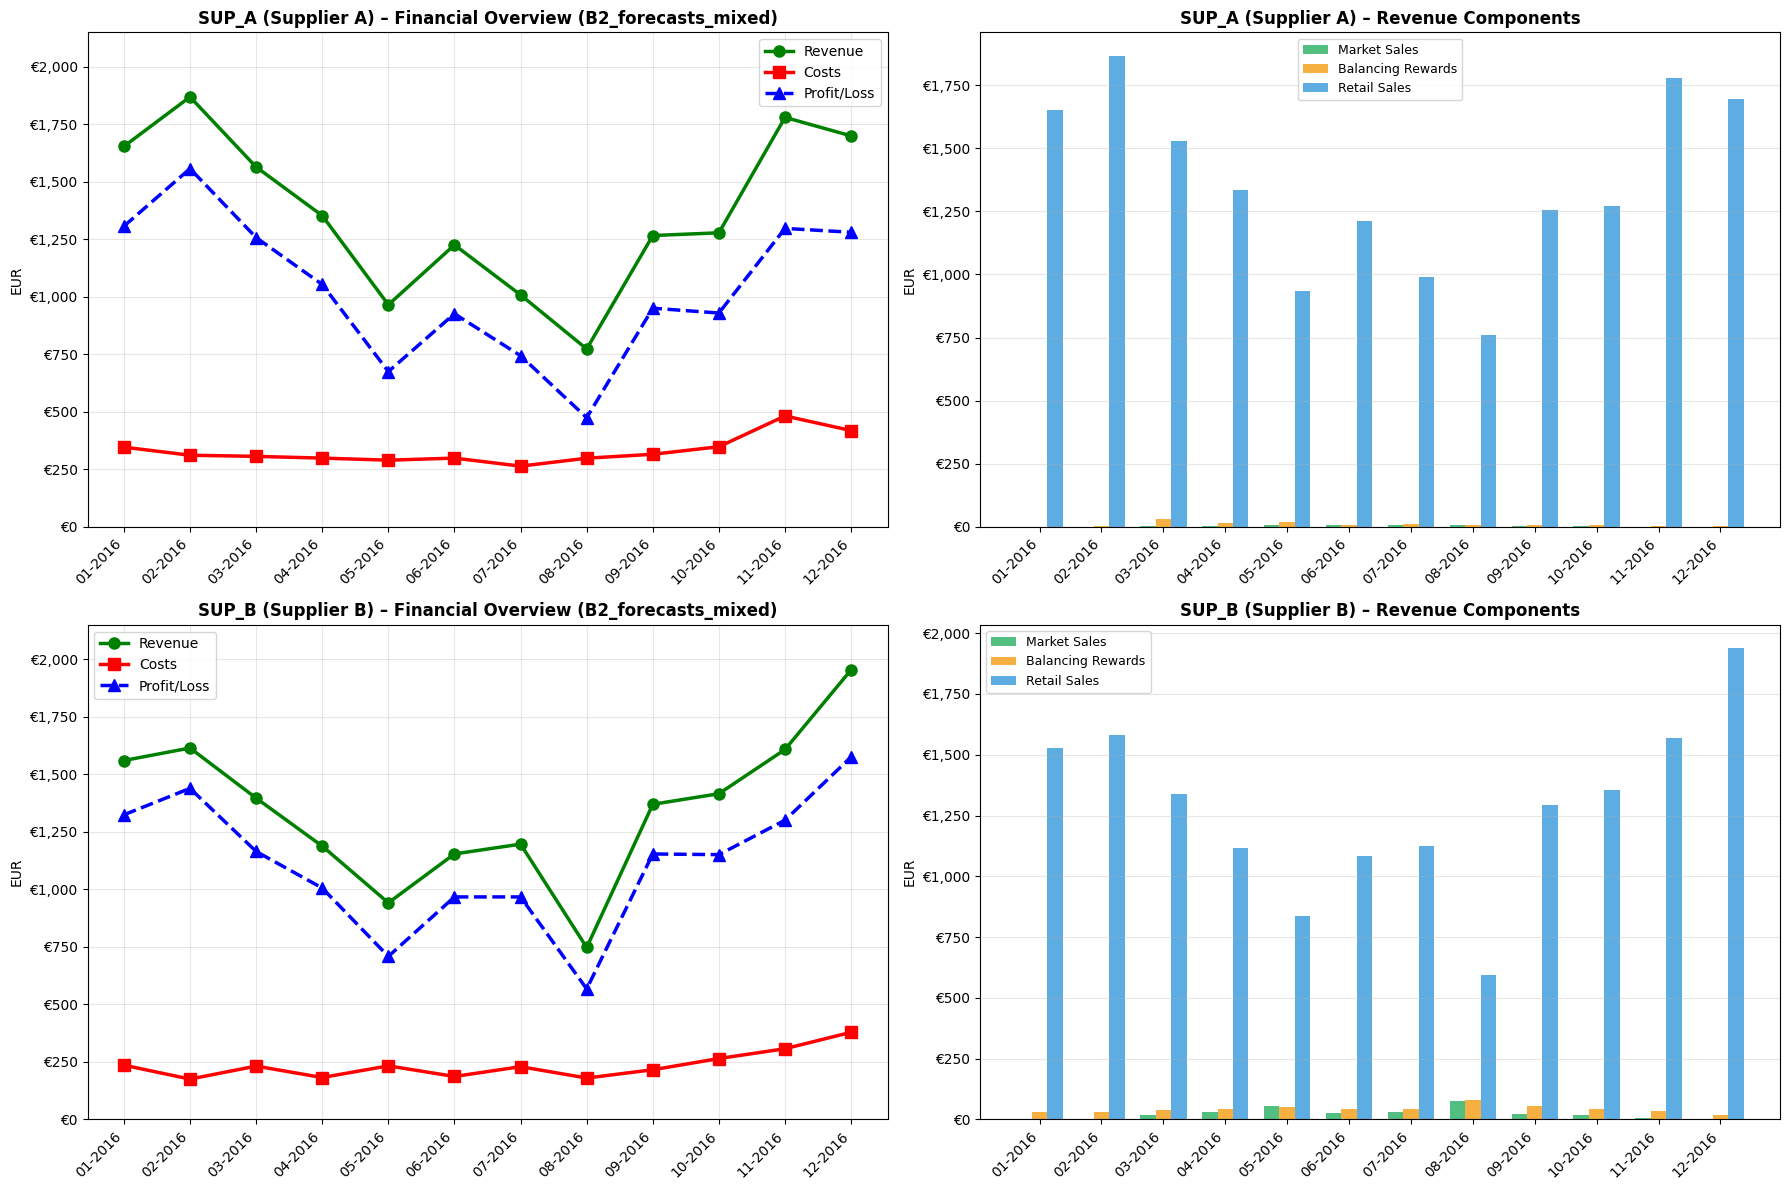

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

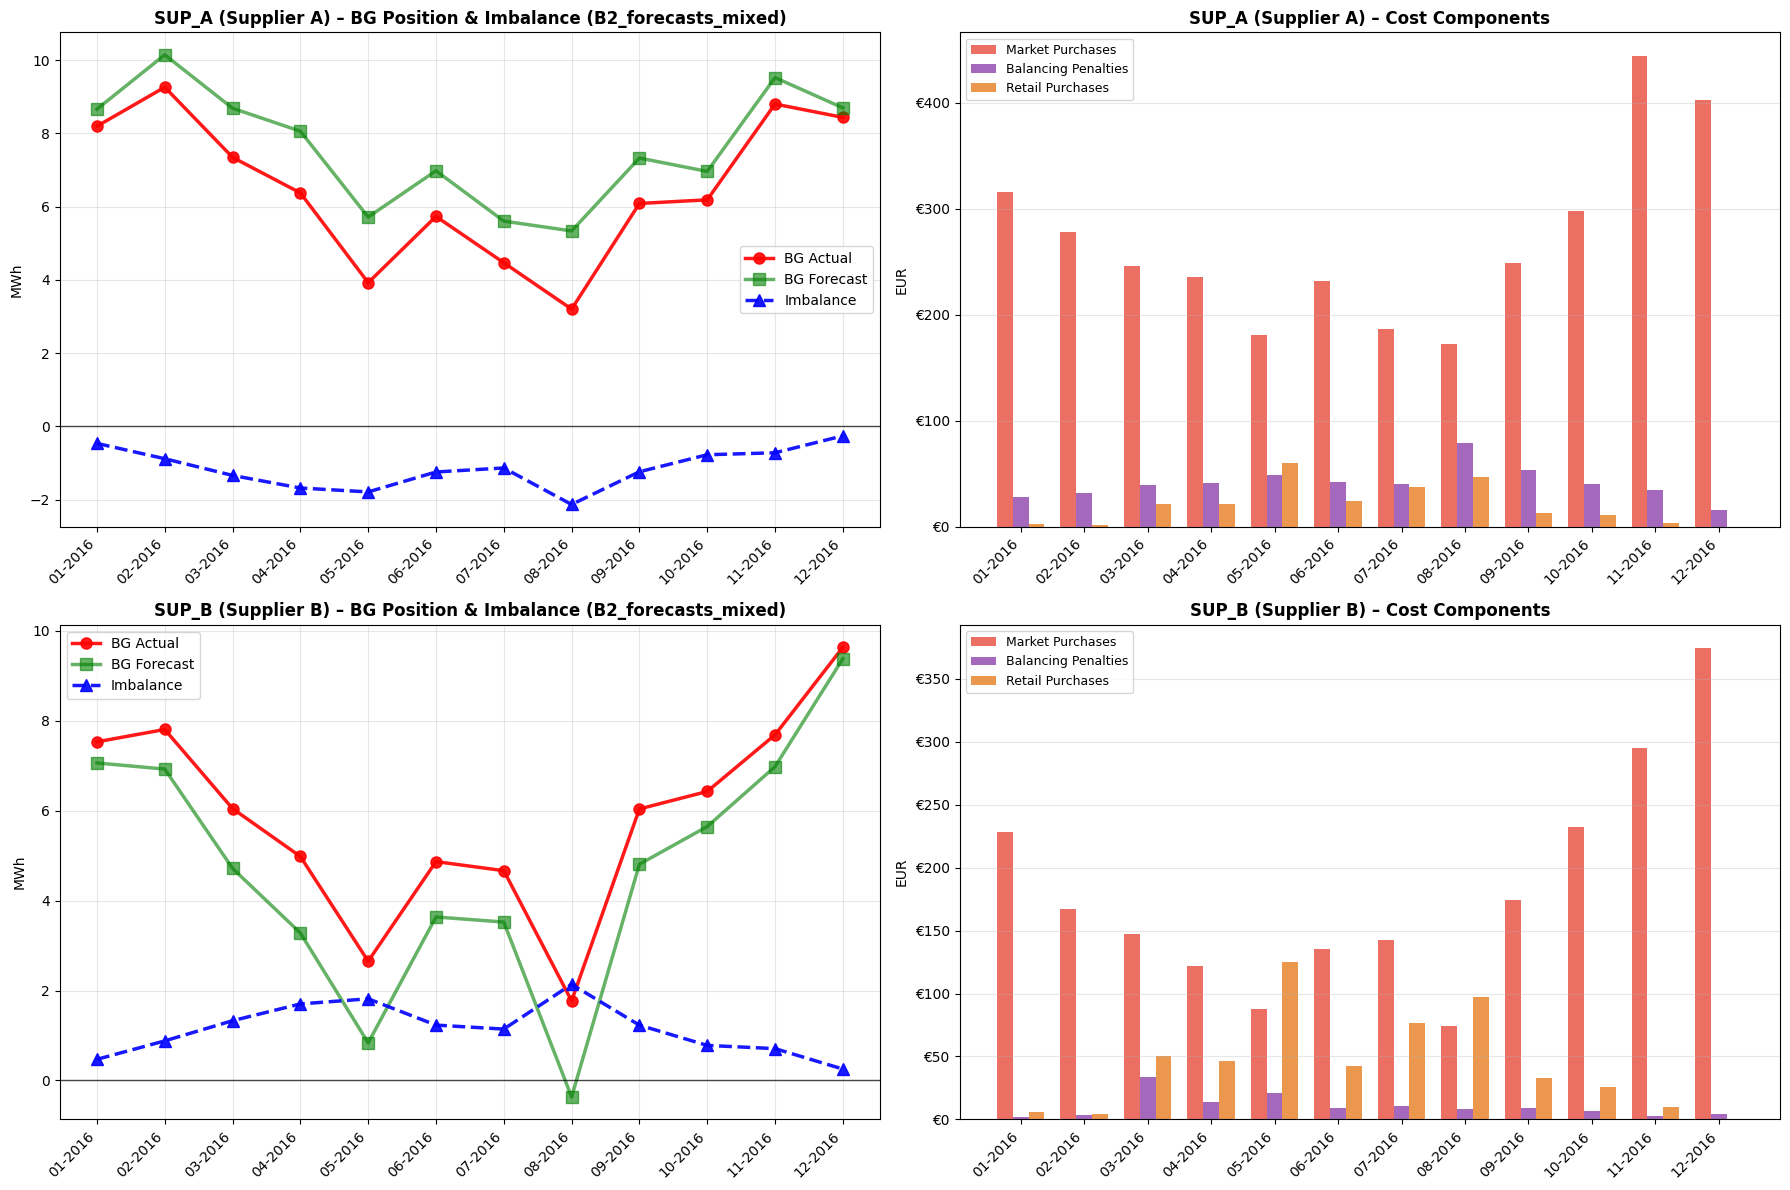

In [6]:
pipe.plot_imbalances()

## 7. Monthly Analysis
Monthly aggregated results including energy volumes, market costs, and REC sharing.

In [8]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,9.577317,0.015500,348.754292,0.339214,-0.897663,0.005667,29.579375,...,1.212396,0.486466,1.217158,1652.384900,1654.088525,316.103887,28.426278,2.322134,346.852299,1307.236225
1,01-2016,SUP_B,BG_B,7.997181,0.100526,254.835818,2.766790,-0.810626,0.025622,29.579375,...,1.847320,3.477123,29.250378,1527.460458,1560.187959,228.642311,1.669052,5.689861,236.001224,1324.186735
2,02-2016,SUP_A,BG_A,11.240043,0.026621,306.976186,0.398334,-1.066581,0.005263,22.463459,...,2.318194,0.481184,3.375165,1865.418452,1869.274800,277.964371,31.879063,1.949661,311.793095,1557.481705
3,02-2016,SUP_B,BG_B,7.904765,0.075700,188.147221,1.436232,-0.865407,0.039448,22.463459,...,2.966928,2.287565,32.283772,1580.029377,1614.600714,167.103488,3.681287,4.647724,175.432500,1439.168214
4,03-2016,SUP_A,BG_A,9.919988,0.222976,272.846897,3.029804,-0.995564,0.018176,24.094009,...,3.914968,3.361146,32.039304,1529.266290,1564.666741,245.630148,39.242894,21.865906,306.738949,1257.927792
5,03-2016,SUP_B,BG_B,6.442443,0.903479,165.643977,16.623708,-0.694212,0.128343,24.094009,...,4.620051,19.681774,39.035449,1338.159446,1396.876670,147.643038,33.850849,50.435469,231.929356,1164.947314
6,04-2016,SUP_A,BG_A,9.302926,0.233464,263.041821,4.394627,-0.986433,0.026957,25.257687,...,5.241609,4.829420,14.052387,1334.423053,1353.304860,235.409265,41.905717,21.975958,299.290940,1054.013920
7,04-2016,SUP_B,BG_B,5.183689,1.136889,137.026704,25.943463,-0.584233,0.183647,25.257687,...,5.915149,30.532898,42.755750,1114.841607,1188.130256,121.458400,14.195646,46.612438,182.266485,1005.863771
8,05-2016,SUP_A,BG_A,7.103709,0.555605,202.737128,7.746405,-0.772611,0.063829,22.993579,...,5.420797,8.759074,21.003366,935.962335,965.724775,180.899842,48.782269,60.594361,290.276472,675.448303
9,05-2016,SUP_B,BG_B,3.994737,2.493847,99.061593,48.372721,-0.451768,0.213402,22.993579,...,6.362072,53.381897,51.196835,837.094261,941.672993,87.544344,20.794280,124.663005,233.001628,708.671365
